In [253]:
# ==========================================================================
# STARTER CODE
# ==========================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings

warnings.filterwarnings("ignore")


housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print(f"Dataset shape: {df.shape}")
print(f"Target: MedHouseVal (median house value in $100k)")
print(df.head())

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Dataset shape: (20640, 9)
Target: MedHouseVal (median house value in $100k)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Training set: 16512 samples
Test set:     4128 samples


               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

<Axes: >

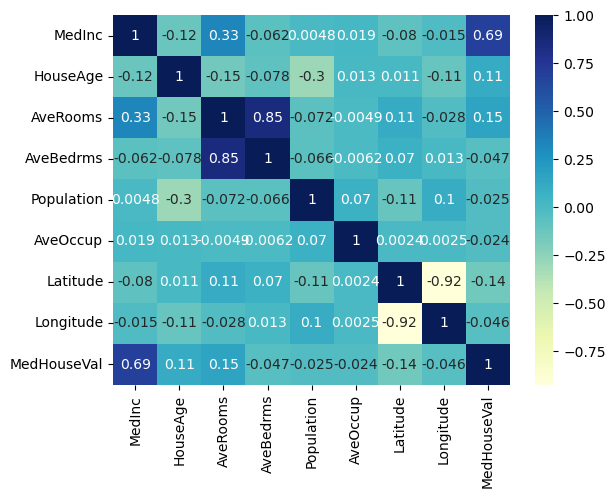

In [254]:
#1a: Create a correlation matrix 
#Calculates how strongly correlated each feature is to every other feature
co_mtx = df.corr()
print(co_mtx)

sns.heatmap(data=co_mtx, cmap="YlGnBu", annot=True)

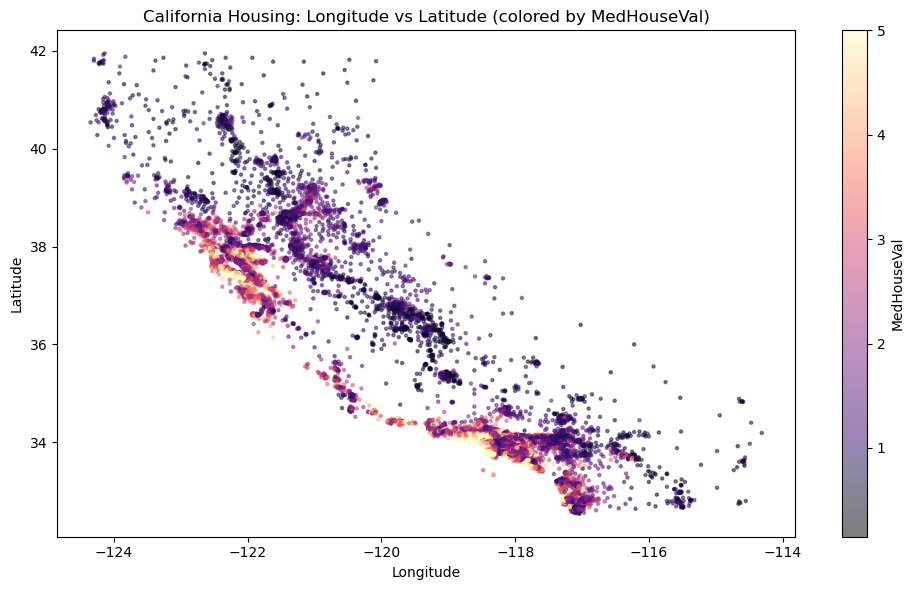

In [255]:
#1b Scatter plot of Longitude vs Latitude colored by MedHouseVal
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["Longitude"], df["Latitude"],
    #Colours each point  based on MedHouseVal
    c=df["MedHouseVal"], cmap="magma",
    s=5, alpha=0.5
)
plt.colorbar(scatter, label="MedHouseVal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing: Longitude vs Latitude (colored by MedHouseVal)")
plt.tight_layout()
plt.show()

#Longitude values are negative in California as its in the western hemeisphere.

In [256]:
#1c. Descriptive Statistics for Train and test sets
train_stats = X_train.describe().T
test_stats = X_test.describe().T

print("Training Set Descriptive Statistics")
print(train_stats)
print("Test Set Descriptive Statistics ")
print(test_stats)

Training Set Descriptive Statistics
              count         mean          std         min         25%  \
MedInc      16512.0     3.880754     1.904294    0.499900    2.566700   
HouseAge    16512.0    28.608285    12.602499    1.000000   18.000000   
AveRooms    16512.0     5.435235     2.387375    0.888889    4.452055   
AveBedrms   16512.0     1.096685     0.433215    0.333333    1.006508   
Population  16512.0  1426.453004  1137.056380    3.000000  789.000000   
AveOccup    16512.0     3.096961    11.578744    0.692308    2.428799   
Latitude    16512.0    35.643149     2.136665   32.550000   33.930000   
Longitude   16512.0  -119.582290     2.005654 -124.350000 -121.810000   

                    50%          75%           max  
MedInc         3.545800     4.773175     15.000100  
HouseAge      29.000000    37.000000     52.000000  
AveRooms       5.235874     6.061037    141.909091  
AveBedrms      1.049286     1.100348     25.636364  
Population  1167.000000  1726.000000  356

In [257]:
#2 Data Preperation
#Looking for missing values in the training and test sets
print("Missing X_train values")
print(X_train.isnull().sum())
print("Missing X_test values")
print(X_test.isnull().sum())



Missing X_train values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Missing X_test values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [258]:
#Look for outliers
for col in X_train:
    print(f"{col}  tail")
    print(X_train[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())

#Winsorize AveRooms, AveBedrms, AveOccup, Population as they have extreme outliers at 99th percentile

MedInc  tail
count    16512.000000
mean         3.880754
std          1.904294
min          0.499900
1%           1.066898
5%           1.599460
50%          3.545800
95%          7.310800
99%         10.576902
max         15.000100
HouseAge  tail
count    16512.000000
mean        28.608285
std         12.602499
min          1.000000
1%           4.000000
5%           8.000000
50%         29.000000
95%         52.000000
99%         52.000000
max         52.000000
AveRooms  tail
count    16512.000000
mean         5.435235
std          2.387375
min          0.888889
1%           2.578195
5%           3.438549
50%          5.235874
95%          7.645946
99%         10.318432
max        141.909091
AveBedrms  tail
count    16512.000000
mean         1.096685
std          0.433215
min          0.333333
1%           0.871161
5%           0.939394
50%          1.049286
95%          1.276685
99%          2.116536
max         25.636364
Population  tail
count    16512.000000
mean      1426.453004


In [259]:
for col in X_test:
    print(f"{col} tail")
    print(X_test[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())

#Winsorise same variables at 99th percentile 

MedInc tail
count    4128.000000
mean        3.830338
std         1.881515
min         0.499900
1%          1.076377
5%          1.603300
50%         3.500000
95%         7.251275
99%        10.795759
max        15.000100
HouseAge tail
count    4128.000000
mean       28.764293
std        12.518304
min         1.000000
1%          4.000000
5%          8.000000
50%        29.000000
95%        52.000000
99%        52.000000
max        52.000000
AveRooms tail
count    4128.000000
mean        5.404059
std         2.794717
min         0.846154
1%          2.628426
5%          3.421648
50%         5.192764
95%         7.628639
99%        10.469400
max       132.533333
AveBedrms tail
count    4128.000000
mean        1.096637
std         0.610196
min         0.500000
1%          0.876786
5%          0.936887
50%         1.046715
95%         1.261315
99%         2.127606
max        34.066667
Population tail
count     4128.000000
mean      1421.571705
std       1114.023136
min          8.000000
1

In [260]:
winsorize_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
#Looks at training datas finding 99th percentile
therehold_99 = X_train[winsorize_cols].quantile(0.99)
therehold_01 = X_train[winsorize_cols].quantile(0.01) 

for col in winsorize_cols:
    upper_limit = therehold_99[col]
    lower_limit = therehold_01[col]
    #Values above the 99th percentile are set to the 99th percentile value
    X_train[col] = X_train[col].clip(upper=upper_limit, lower=lower_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit, lower=lower_limit)

for col in winsorize_cols:
    print(f"\n=== {col} upper tail ===")
    print(X_train[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())



=== AveRooms upper tail ===
count    16512.000000
mean         5.342542
std          1.320156
min          2.578195
1%           2.578212
5%           3.438549
50%          5.235874
95%          7.645946
99%         10.315997
max         10.318432

=== AveBedrms upper tail ===
count    16512.000000
mean         1.077676
std          0.158122
min          0.871161
1%           0.871334
5%           0.939394
50%          1.049286
95%          1.276685
99%          2.115940
max          2.116536

=== AveOccup upper tail ===
count    16512.000000
mean         2.915082
std          0.733002
min          1.538838
1%           1.538850
5%           1.872511
50%          2.817240
95%          4.333333
99%          5.408202
max          5.410157

=== Population upper tail ===
count    16512.000000
mean      1405.080595
std        972.236237
min         88.110000
1%          88.207900
5%         349.000000
50%       1167.000000
95%       3282.450000
99%       5794.020800
max       5798.720000


In [261]:
for col in winsorize_cols:
    print(f"\n=== {col} upper tail ===")
    print(X_test[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())


=== AveRooms upper tail ===
count    4128.000000
mean        5.298667
std         1.320081
min         2.578195
1%          2.628426
5%          3.421648
50%         5.192764
95%         7.628639
99%        10.318432
max        10.318432

=== AveBedrms upper tail ===
count    4128.000000
mean        1.074060
std         0.156657
min         0.871161
1%          0.876786
5%          0.936887
50%         1.046715
95%         1.261315
99%         2.116536
max         2.116536

=== AveOccup upper tail ===
count    4128.000000
mean        2.922376
std         0.731928
min         1.538838
1%          1.538838
5%          1.874175
50%         2.823586
95%         4.336877
99%         5.375092
max         5.410157

=== Population upper tail ===
count    4128.000000
mean     1399.383915
std       974.163918
min        88.110000
1%         88.110000
5%        341.350000
50%      1160.000000
95%      3325.650000
99%      5798.720000
max      5798.720000


In [262]:
#3a
# Compute skewness of every feature in X_train
skewness = X_train.skew()
print("Skewness of all features:")
print(skewness)
print()

#Find features where skeweness exceeds 1
high_skew_features = skewness[skewness.abs() > 1.0].index.tolist()


#Applying log1p to features in Train and test
for features in high_skew_features:
    X_train[features] = np.log1p(X_train[features])
    X_test[features] = np.log1p(X_test[features])



print("Skewness AFTER log1p transform:")
print(X_train.skew())
print()

#Computer skewness of y
y_skew = y_train.skew()
print(f"Skewness of y_train: {y_skew:.4f}")


y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print(f"Skewness of y_train_log: {y_train_log.skew():.4f}")


Skewness of all features:
MedInc        1.634090
HouseAge      0.063453
AveRooms      0.794983
AveBedrms     4.116452
Population    1.953823
AveOccup      0.868235
Latitude      0.461504
Longitude    -0.288418
dtype: float64

Skewness AFTER log1p transform:
MedInc        0.216093
HouseAge      0.063453
AveRooms      0.794983
AveBedrms     3.430540
Population   -0.677150
AveOccup      0.868235
Latitude      0.461504
Longitude    -0.288418
dtype: float64

Skewness of y_train: 0.9765
Skewness of y_train_log: 0.2772


In [263]:
#3b
#Los Angeles coordinates
LA_LAT, LA_LON = 34.0522, -118.2437
#Calculate Euclidean distance to LA
X_train['dist_to_la'] = np.sqrt(
    (X_train['Latitude'] - LA_LAT)**2 + (X_train['Longitude'] - LA_LON)**2
)
X_test['dist_to_la'] = np.sqrt(
    (X_test['Latitude'] - LA_LAT)**2 + (X_test['Longitude'] - LA_LON)**2
)

#San Francisco coordinates
SF_LAT, SF_LON = 37.7749, -122.4194

X_train['dist_to_sf'] = np.sqrt(
    (X_train['Latitude'] - SF_LAT)**2 + (X_train['Longitude'] - SF_LON)**2
)
X_test['dist_to_sf'] = np.sqrt(
    (X_test['Latitude'] - SF_LAT)**2 + (X_test['Longitude'] - SF_LON)**2
)
#Coastline Coordinates
COAST_POINTS = np.array([

    [41.75, -124.19],  # Crescent City
    [40.80, -124.16],  # Eureka
    [37.77, -122.51],  # San Francisco
    [36.97, -122.02],  # Santa Cruz
    [35.90, -121.48],  # Big Sur
    [34.02, -118.49],  # Santa Monica
    [33.72, -118.29],  # Long Beach
    [32.72, -117.17],  # San Diego
    
])

def dist_to_coastline(lat, lon):
    dists = np.sqrt(
        (COAST_POINTS[:, 0] - lat)**2 + (COAST_POINTS[:, 1] - lon)**2
    )
    return dists.min()

X_train['dist_to_coast'] = [
    dist_to_coastline(lat, lon)
    for lat, lon in zip(X_train['Latitude'], X_train['Longitude'])
]
X_test['dist_to_coast'] = [
    dist_to_coastline(lat, lon)
    for lat, lon in zip(X_test['Latitude'], X_test['Longitude'])
]

print(X_train[['dist_to_la', 'dist_to_sf', 'dist_to_coast']].describe())




         dist_to_la    dist_to_sf  dist_to_coast
count  16512.000000  16512.000000   16512.000000
mean       2.657266      3.864622       0.679216
std        2.418615      2.499218       0.631174
min        0.004305      0.004937       0.000000
25%        0.323364      1.201885       0.226716
50%        1.702949      5.256712       0.410122
75%        5.209711      5.845319       1.088531
max        9.865526      9.310053       3.784283


In [264]:
#4a
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


In [265]:
#4b

model = LinearRegression()
#Trains model via scaled training data andlog transformed train data
model.fit(X_train_scaled, y_train_log)

print(f"Intercept: {model.intercept_:.4f}")
for name, coef in zip(X_train.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")

Intercept: 1.0571
  MedInc: 0.2103
  HouseAge: 0.0154
  AveRooms: -0.0089
  AveBedrms: 0.0383
  Population: 0.0046
  AveOccup: -0.0801
  Latitude: -0.1311
  Longitude: -0.1893
  dist_to_la: -0.1007
  dist_to_sf: -0.0305
  dist_to_coast: -0.0845


In [266]:
#4c

# Predicts house values for train and test data in log scale
y_train_pred_log = model.predict(X_train_scaled)
y_test_pred_log  = model.predict(X_test_scaled)

# Expm1 Reverses log1p transformation done in 3a
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred  = np.expm1(y_test_pred_log)

# Calculates RMSE and R² 
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
#Meaasures how well the model explains variance in data 1 ideal 0 no better then guessing average 
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)

print("=== Model Performance (Original Scale) ===")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test  R²:   {test_r2:.4f}")

=== Model Performance (Original Scale) ===
Train RMSE: 0.6449
Test  RMSE: 0.6567
Train R²:   0.6889
Test  R²:   0.6709


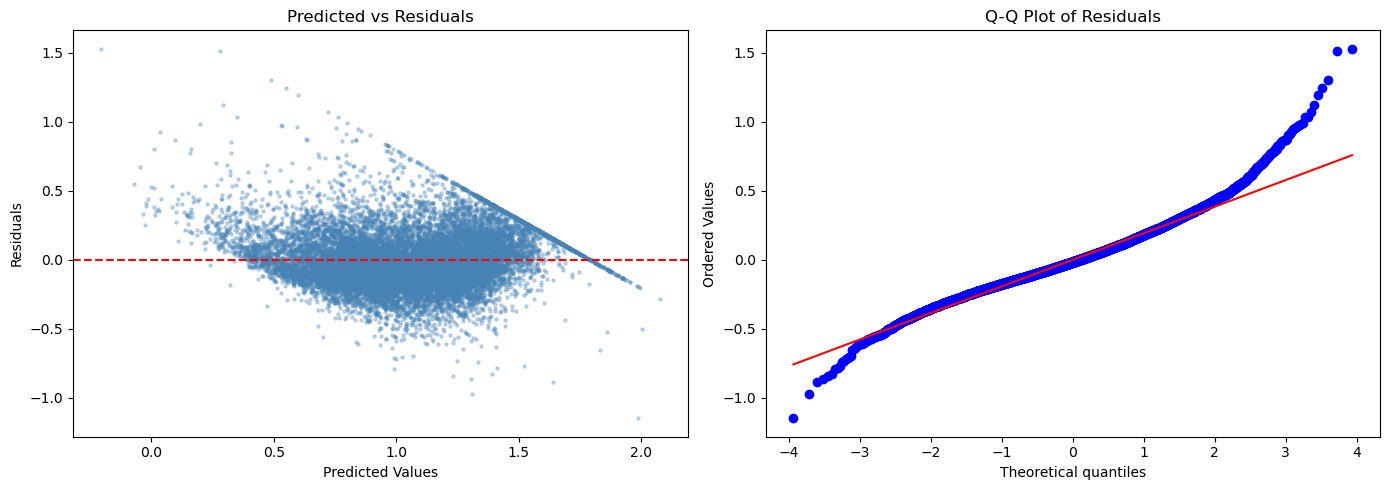

In [267]:
#Predicts house values for train data in in log scale
y_train_pred_log = model.predict(X_train_scaled)
#Calculates residuals in log scale
residuals = y_train_log - y_train_pred_log

# --- Create figure with 2 subplots side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Predicted vs Residuals ---
axes[0].scatter(y_train_pred_log, residuals, alpha=0.3, s=5, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Predicted vs Residuals")

# --- Plot 2: Q-Q Plot ---
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()